<a href="https://colab.research.google.com/github/bnsreenu/python_for_microscopists/blob/master/334_training_YOLO_V8_EM_platelets_converted_labels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


In [1]:
import torch
print(torch.cuda.is_available())

if 'model' in globals():
    del model
    
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

True


*******Predict******

In [2]:
import os
from ultralytics import YOLO
%matplotlib inline
from matplotlib import pyplot as plt
from PIL import Image
import torch

#List the saved models in 'runs' directory. Note that you will see multiple 'train' subdirectories numbered 1, 2, 3, etc. The exact number depends on the number of epochs.
#%ls E:\University\Finalproject\BeeCount\Main\Yolo\Results\960\400+patience20_epochs_32+353\weights

#Define a project --> Destination directory for all results
project = "E:\\Euglena\\segment\\"

#Define subdirectory for this specific training
name = "v.1-1280-P" 

device = 'cuda' if torch.cuda.is_available() else 'cpu'
my_new_model = YOLO('E:\\EUGLENA\\Results\\P\\1280\\1280_batch4_100epochs6\\weights\\best.pt').to(device)

new_image = "E:\\EUGLENA\\Pictures\\Main_jpg\\P-JPG\\P-5-3.jpg" 

# Prediction
new_results = my_new_model.predict(new_image, project=project, save=True, name=name, imgsz=1280, conf=0.6, show_labels=False, max_det=1000)  #Adjust conf threshold #show_labels=False 



WARNING Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\beckh\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 E:\EUGLENA\Pictures\Main_jpg\P-JPG\P-5-3.jpg: 1280x1280 14 Black dots, 13.6ms
Speed: 11.5ms preprocess, 13.6ms inference, 19.2ms postprocess per image at shape (1, 3, 1280, 1280)
Results saved to E:\EUGLENA\segment\v.1-1280-P6


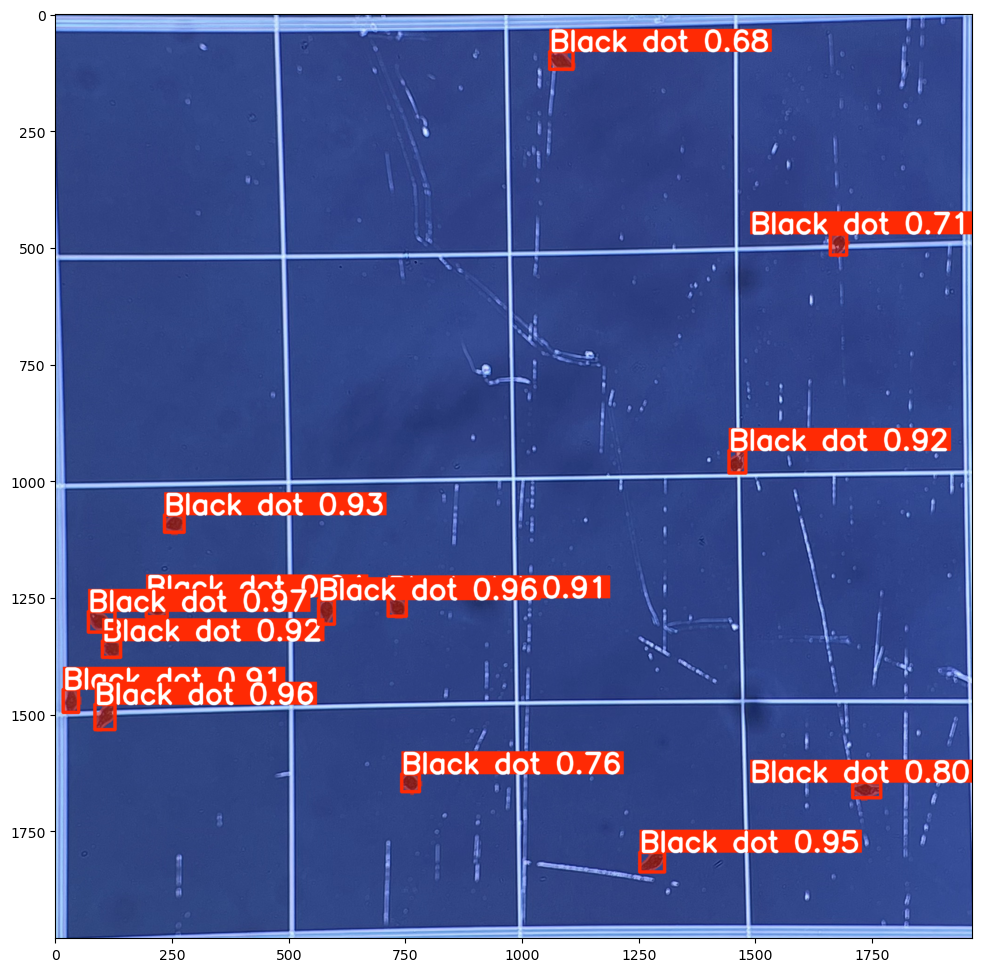

In [11]:
    new_result_array = new_results[0].plot()
    plt.figure(figsize=(12, 12))
    plt.imshow(new_result_array)


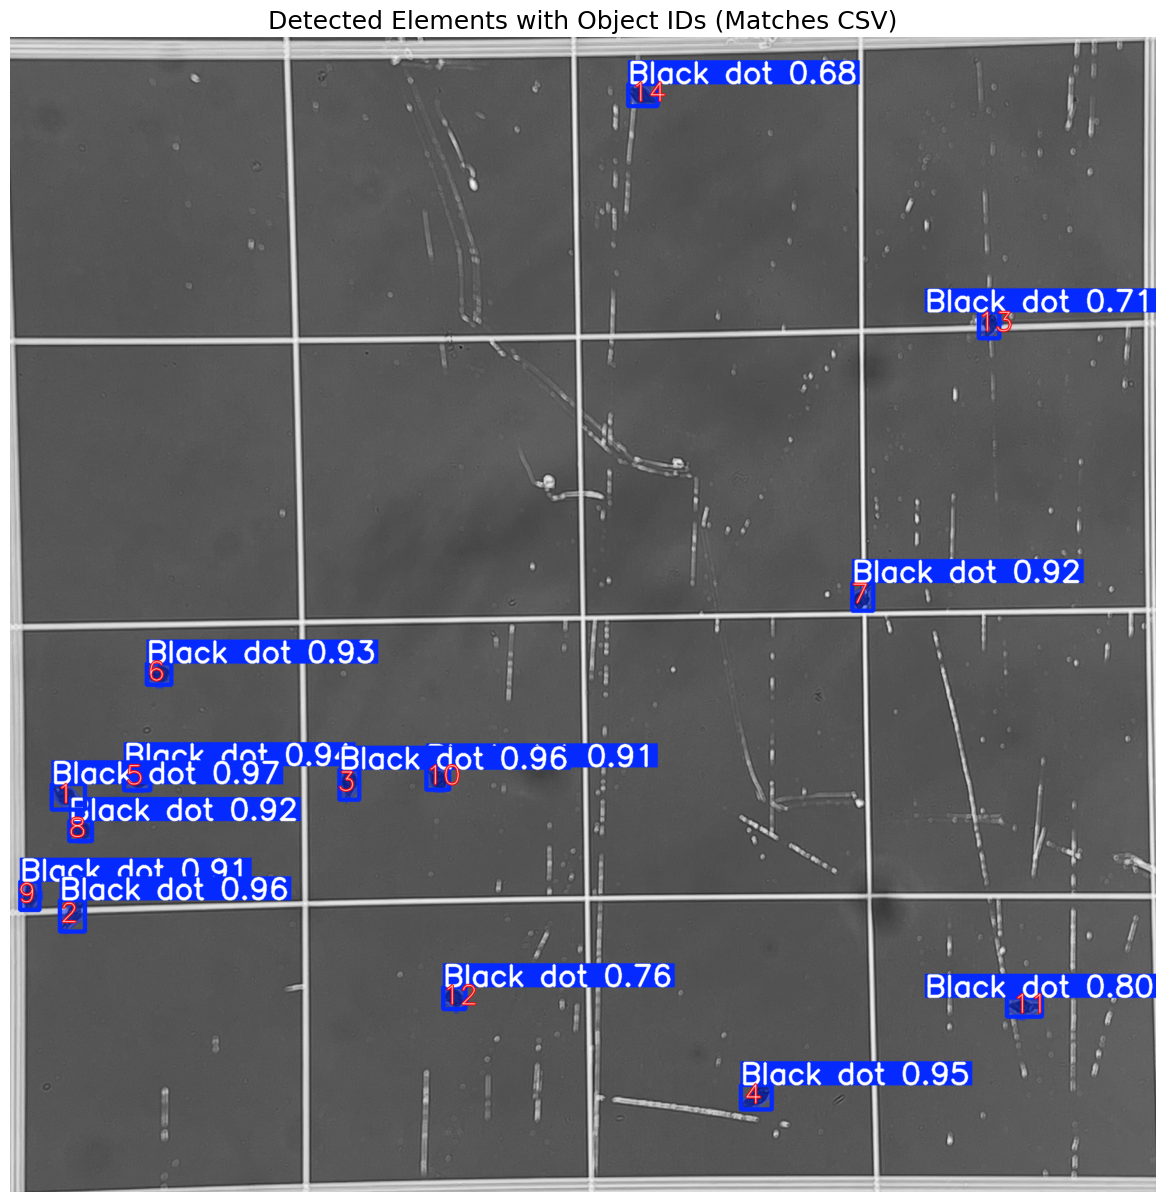

In [21]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

orig_image = new_results[0].orig_img
gray_image = cv2.cvtColor(orig_image, cv2.COLOR_BGR2GRAY)

gray_bg_3channel = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)

new_result_array = new_results[0].plot(img=gray_bg_3channel, line_width=5, font_size=5)

# Iterate through detected boxes to draw Object IDs
if new_results[0].boxes is not None:
    detected_boxes = new_results[0].boxes.data
    for i, box_data in enumerate(detected_boxes):
        # Get bounding box coordinates (xmin, ymin, xmax, ymax)
        x0, y0, x1, y1 = box_data[:4].cpu().numpy()
        center_x = int((x0 + x1) / 2)
        center_y = int((y0 + y1) / 2)
        
        # Add Object ID (i+1) at the center of the box
        # Use Red color (0,0,255) in BGR to stand out
        cv2.putText(new_result_array, f'{i+1}', (center_x-20, center_y+10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 4, cv2.LINE_AA)
        # Add a white border/shadow to text so it's readable on varying backgrounds
        cv2.putText(new_result_array, f'{i+1}', (center_x-20, center_y+10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 1, cv2.LINE_AA)

plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(new_result_array, cv2.COLOR_BGR2RGB))
plt.title('Detected Elements with Object IDs (Matches CSV)', fontsize=18)
plt.axis('off')
plt.show()


-----

Push the mask to cpu (from GPU) and convert to numpy array for easy plotting.

In [23]:
result = new_results[0]

In [24]:
new_results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'Black dot'}
 obb: None
 orig_img: array([[[ 46,  67, 122],
         [ 46,  67, 122],
         [ 45,  66, 121],
         ...,
         [183, 216, 255],
         [168, 201, 250],
         [151, 186, 242]],
 
        [[ 57,  80, 136],
         [ 56,  79, 135],
         [ 55,  78, 134],
         ...,
         [179, 214, 254],
         [167, 201, 254],
         [154, 188, 247]],
 
        [[ 70,  94, 152],
         [ 69,  93, 151],
         [ 68,  92, 150],
         ...,
         [172, 205, 251],
         [163, 196, 252],
         [152, 187, 250]],
 
        ...,
 
        [[138, 169, 232],
         [148, 182, 242],
         [159, 198, 253],
         ...,
         [160, 189, 246],
         [159, 188, 245],
         [158, 188, 243]],
 
        [[136, 167, 230],
         [147, 181, 241],
         [158, 198, 

In [25]:
result.masks.xyn

[array([[   0.035307,     0.64531],
        [   0.035307,     0.65938],
        [    0.03767,     0.65938],
        [   0.040033,     0.66172],
        [   0.040033,      0.6625],
        [   0.042396,     0.66484],
        [   0.043184,     0.66484],
        [   0.044759,     0.66641],
        [   0.046334,     0.66641],
        [   0.047122,     0.66719],
        [   0.050272,     0.66719],
        [    0.05106,     0.66797],
        [   0.055785,     0.66797],
        [   0.056573,     0.66875],
        [   0.063662,     0.66875],
        [   0.065237,     0.66719],
        [   0.065237,     0.66406],
        [   0.064449,     0.66328],
        [   0.064449,      0.6625],
        [   0.061299,     0.65938],
        [   0.061299,     0.65859],
        [   0.059723,     0.65703],
        [   0.059723,     0.65625],
        [   0.057361,     0.65391],
        [   0.057361,     0.65312],
        [   0.053423,     0.64922],
        [   0.051847,     0.64922],
        [   0.050272,     0.

In [26]:
extracted_masks = result.masks.data

In [27]:
extracted_masks.shape

torch.Size([14, 1280, 1280])

In [28]:
masks_array = extracted_masks.cpu().numpy()
print(masks_array.shape)

(14, 1280, 1280)


เช็คเลข

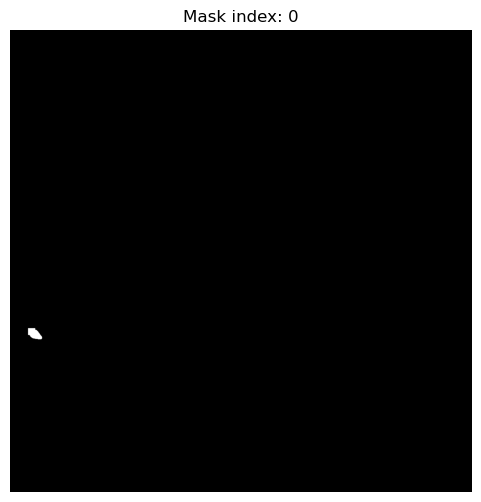

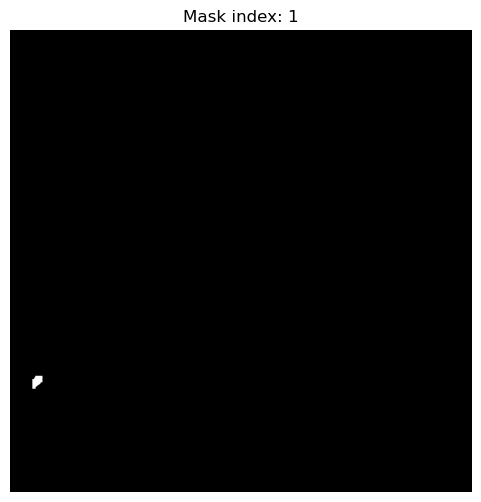

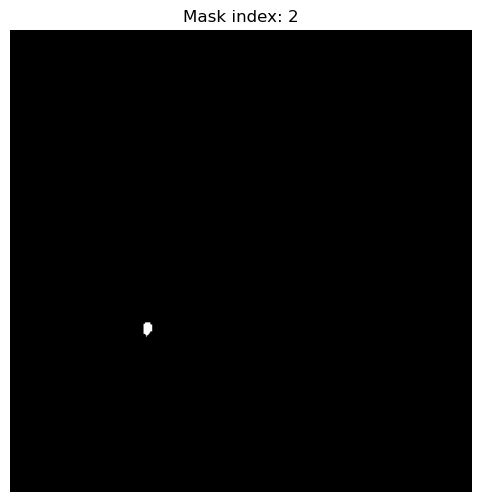

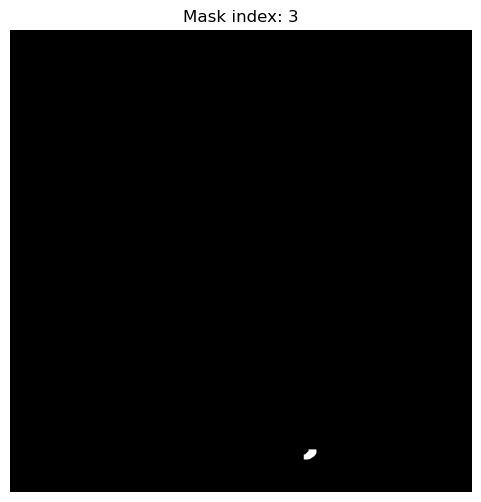

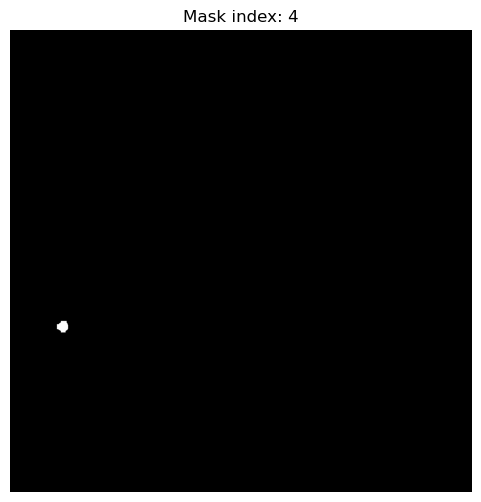

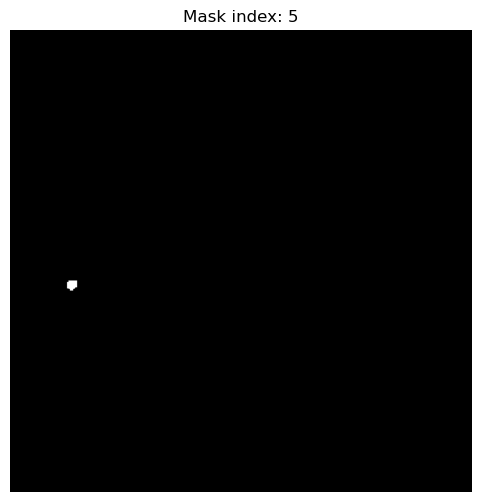

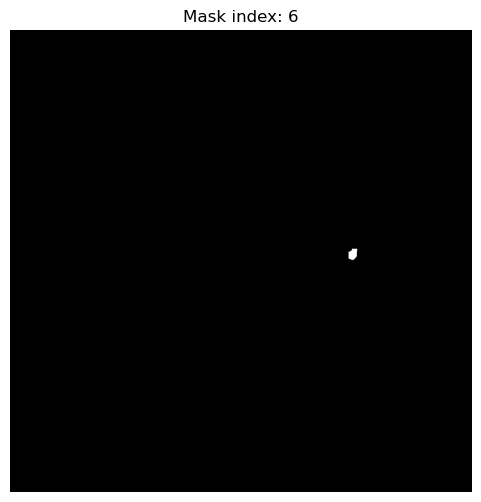

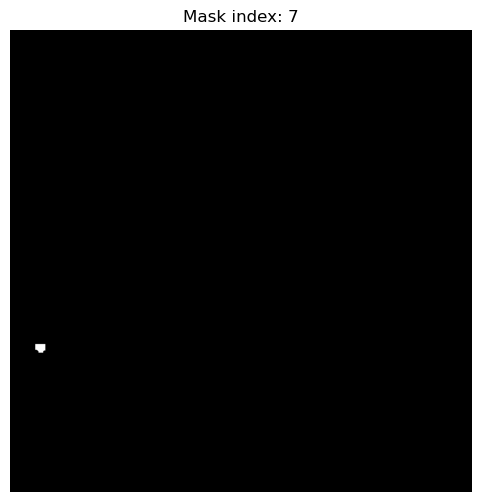

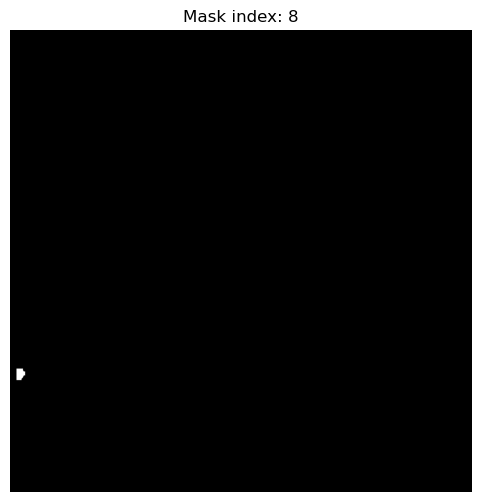

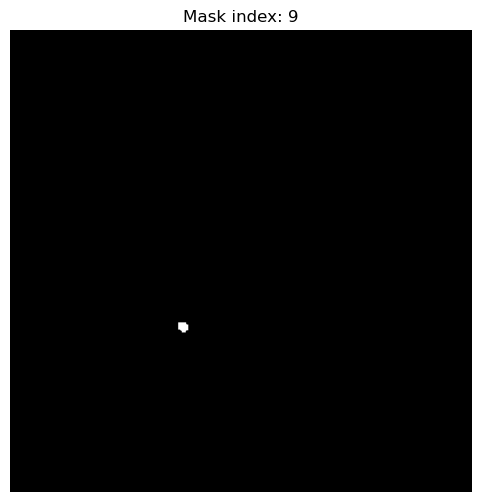

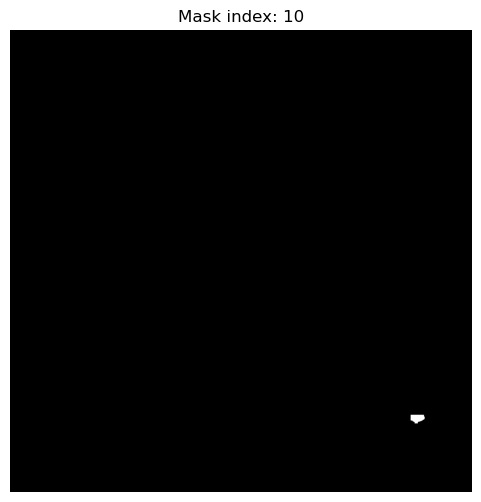

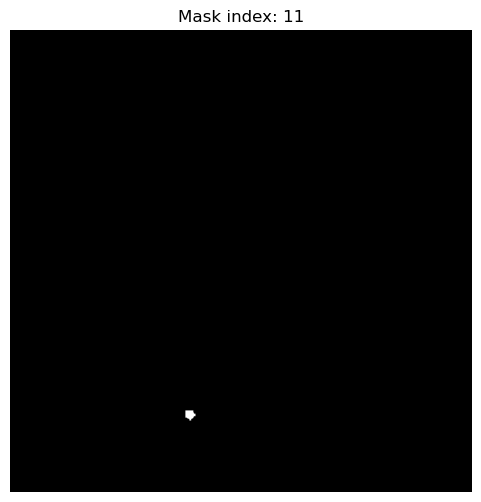

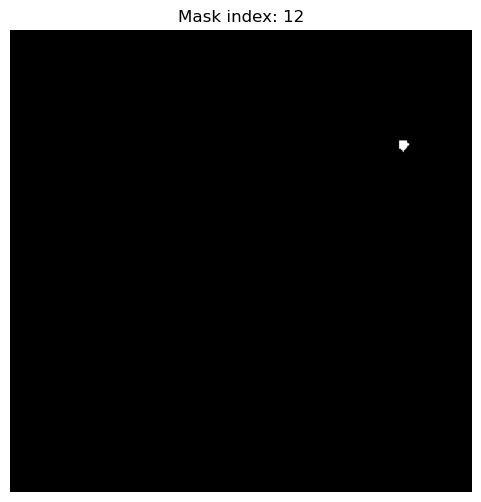

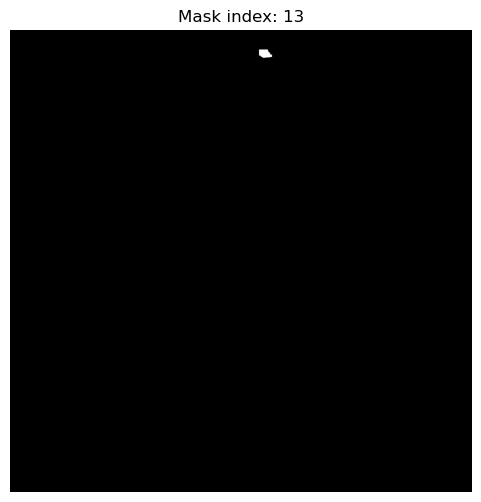

In [10]:
import matplotlib.pyplot as plt

for i in range(len(masks_array)):
    # Handle possible shape variations
    if masks_array.ndim == 4:
        mask = masks_array[i, 0]  # shape: (N, 1, H, W)
    elif masks_array.ndim == 3:
        mask = masks_array[i]     # shape: (N, H, W)
    elif masks_array.dtype == object:
        mask = masks_array[i]     # shape: (H, W), object array
    else:
        raise ValueError("Unsupported mask array shape")

    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask index: {i}")
    plt.axis('off')
    plt.show()

(14, 1280, 1280)


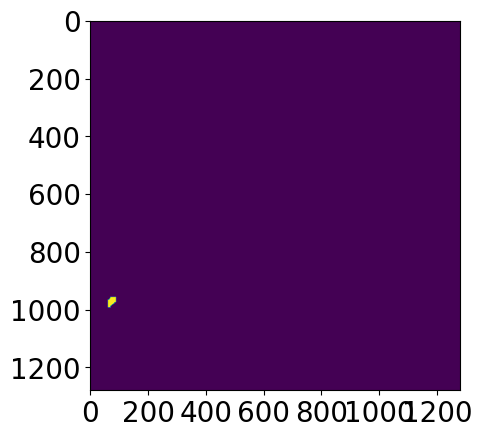

In [11]:
masks_array = extracted_masks.cpu().numpy()
print(masks_array.shape)

plt.imshow(masks_array[1])

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.savefig("E:\\Euglena\\scalebar\\mask_with_scalebar-.png", dpi=500, bbox_inches='tight')

In [12]:
masks_array = extracted_masks.cpu().numpy()

plt.imshow(masks_array[54])

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.savefig("E:\\University\\Finalproject\\report\\picture\\mask_with_scalebar-3.png", dpi=500, bbox_inches='tight')

IndexError: index 54 is out of bounds for axis 0 with size 14

Plot ขนาด

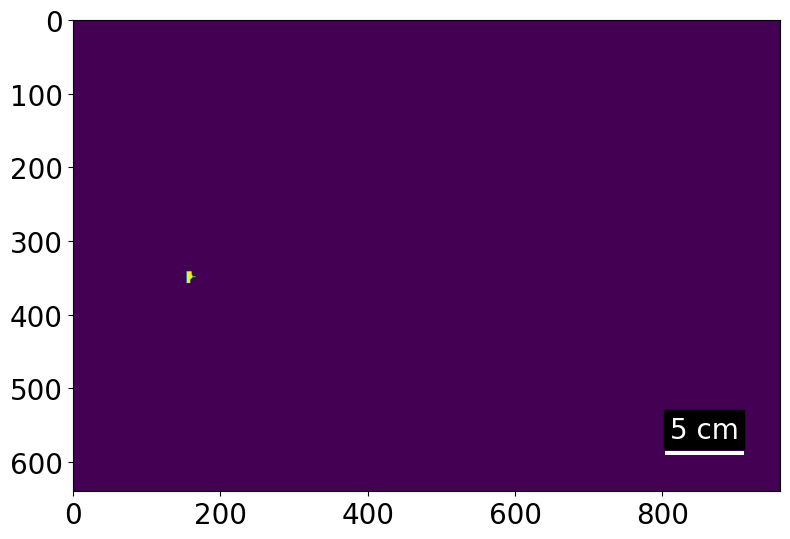

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

masks_array = extracted_masks.cpu().numpy()
mask = masks_array[1]  # 2D array

# Image dimensions
h, w = mask.shape

# 🔁 Updated conversion: full image width = 45 cm
known_cm = 45
cm_per_px = known_cm / w
px_per_cm = w / known_cm

# Set scale bar length (e.g., 5 cm)
bar_cm = 5
bar_px = bar_cm * px_per_cm

# Padding and bar size
pad = 50
bar_height = 5

# Bottom-right positioning with leftward shift
scalebar_x = w - bar_px - pad
scalebar_y = h - pad - bar_height

plt.figure(figsize=(8, 6))
plt.imshow(mask, cmap='viridis')

# Draw scale bar
plt.gca().add_patch(patches.Rectangle(
    (scalebar_x, scalebar_y),
    bar_px,
    bar_height,
    facecolor='white',
    edgecolor='none'
))

# Label it “5 cm”
plt.text(
    scalebar_x + bar_px / 2,
    scalebar_y - 10,
    f'{bar_cm} cm',
    color='white',
    ha='center',
    va='bottom',
    fontsize=20,
    backgroundcolor='black'
)

# Axis styling
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.axis('on')
plt.tight_layout()

# Save output
plt.savefig("E:\\University\\Finalproject\\report\\picture\\mask_with_scalebar-.png", dpi=300, bbox_inches='tight')
plt.show()

**Calculating region properties for all objects and saving to a csv file.**

-------

Starting analysis with unit conversion (Scale: 0.000563508 mm/px)...
Original Image Shape: 1964x1980
Analysis saved to: E:\EUGLENA\CSV\BlackDot_Analysis_TEST.csv
------------------------------
Calibration used: 0.000563508 mm/px
------------------------------
   Object ID Class Name  Confidence  Width (mm)  Length (mm)  Area (mm^2)  \
0          1  Black dot      0.9667    0.021237     0.039214     0.000639   
1          2  Black dot      0.9638    0.020314     0.035984     0.000546   
2          3  Black dot      0.9596    0.021704     0.032997     0.000546   
3          4  Black dot      0.9478    0.018962     0.036044     0.000526   
4          5  Black dot      0.9366    0.026664     0.028221     0.000573   

   Width (px)  Length (px)  Area (px^2)  
0   37.686604    69.589665       2011.0  
1   36.048557    63.857863       1718.0  
2   38.516016    58.556499       1719.0  
3   33.650770    63.963489       1656.0  
4   47.317448    50.081765       1803.0  
Plotted image with IDs sa

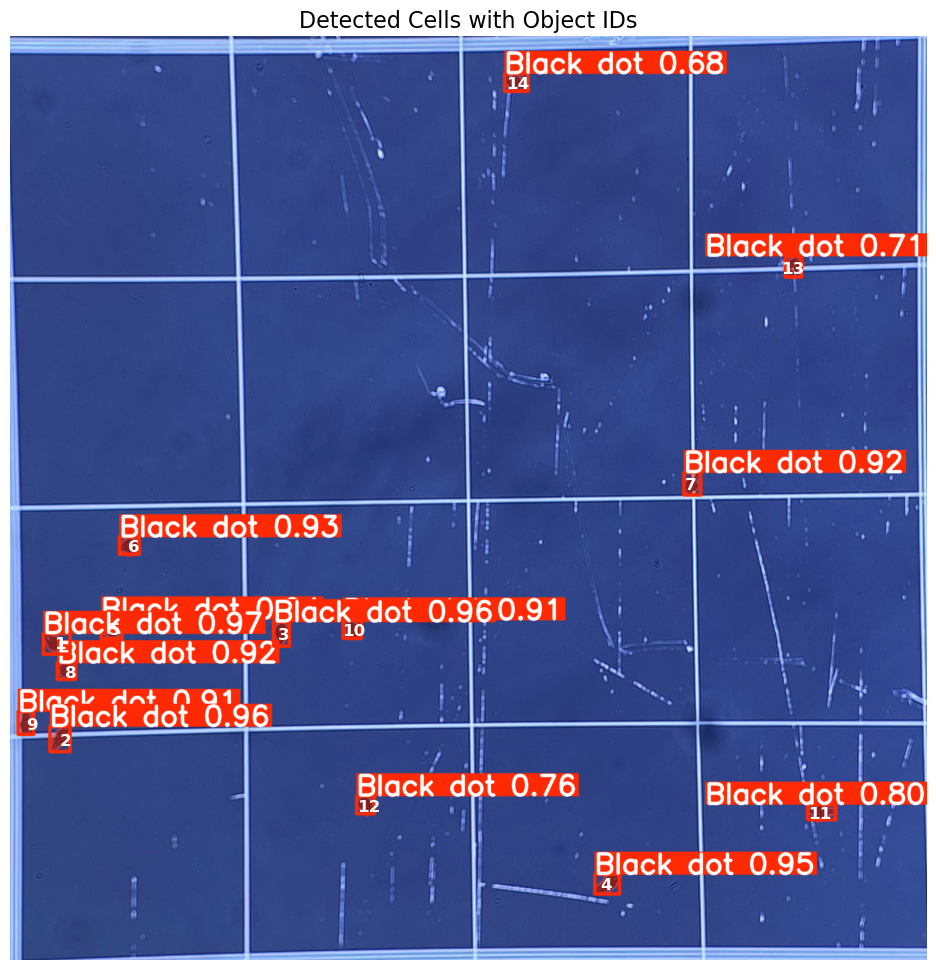

: 

In [ ]:
import pandas as pd
import numpy as np
import cv2
from skimage.measure import regionprops
import os
import matplotlib.pyplot as plt

# mm/px factor เอาไว้แปลง pixel เป็น mm 
MILLIMETERS_PER_PIXEL = 0.000563508
# ---------------------

print(f"Starting analysis with unit conversion (Scale: {MILLIMETERS_PER_PIXEL} mm/px)...")

if 'new_results' in locals():
    new_result = new_results[0]
    
    # Get original image dimensions (Height, Width)
    orig_h, orig_w = new_result.orig_shape[:2]
    print(f"Original Image Shape: {orig_w}x{orig_h}")

    extracted_masks = new_result.masks.data
    detected_boxes = new_result.boxes.data
    
    # จุดที่ดึงค่าออกมา
    if detected_boxes is not None and len(detected_boxes) > 0:
        class_labels = detected_boxes[:, -1].int().tolist()
        conf_scores = detected_boxes[:, -2].float().tolist()
    else:
        class_labels = []
        conf_scores = []

    props_list = []
    
    # --- Prepare image for plotting ---
    new_result_array = new_results[0].plot()
    plt.figure(figsize=(12, 12))
    plt.imshow(new_result_array)
 
    if len(class_labels) == len(extracted_masks):
        for i, (mask, class_id, conf) in enumerate(zip(extracted_masks, class_labels, conf_scores)):
            class_name = new_result.names[class_id]
            
            # Convert to numpy and resize to original image dimensions
            mask_np = mask.cpu().numpy().astype('uint8')
            mask_resized = cv2.resize(mask_np, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
            
            props = regionprops(mask_resized)
            for prop in props:
                # 1. นับจำนวน pixel ทั้งหมดที่ detect คลุมดำตัวเซล
                area_px = prop.area
                
                # 2. วัดความยาวแกนและความกว้างแกนของเซล
                axis_length_px = prop.major_axis_length # กว้าง
                axis_width_px = prop.minor_axis_length
           
                final_length_px = axis_length_px
                final_width_px = axis_width_px

                # Convert to mm
                final_width_mm = final_width_px * MILLIMETERS_PER_PIXEL
                final_length_mm = final_length_px * MILLIMETERS_PER_PIXEL
                area_mm2 = area_px * (MILLIMETERS_PER_PIXEL ** 2)

                obj_id = i + 1
                # ตาราง column สร้างเพิ่ม Confidence
                props_list.append({
                    'Object ID': obj_id,
                    'Class Name': class_name,
                    'Confidence': round(conf, 4),
                    'Width (mm)': final_width_mm,
                    'Length (mm)': final_length_mm,
                    'Area (mm^2)': area_mm2,
                    'Width (px)': final_width_px,
                    'Length (px)': final_length_px,
                    'Area (px^2)': area_px,
                })
                
                # --- Plot Object ID ---
                y0, x0, y1, x1 = prop.bbox
                center_x = (x0 + x1) / 2
                center_y = (y0 + y1) / 2
                plt.text(center_x, center_y, str(obj_id), color='white', fontsize=12, fontweight='bold', ha='center', va='center')

        props_df = pd.DataFrame(props_list)

        # Save to CSV
        output_csv_path = r'E:\EUGLENA\CSV\BlackDot_Analysis_TEST.csv'
        os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)
        props_df.to_csv(output_csv_path, index=False)

        print(f"Analysis saved to: {output_csv_path}")
        print("-" * 30)
        print(f"Calibration used: {MILLIMETERS_PER_PIXEL} mm/px")
        print("-" * 30)
        print(props_df.head())
        
        # Finish plotting
        plt.title("Detected Cells with Object IDs", fontsize=16)
        plt.axis('off')
        output_img_path = r'E:\EUGLENA\CSV\BlackDot_Analysis_Plot.png'
        plt.savefig(output_img_path, dpi=300, bbox_inches='tight')
        print(f"Plotted image with IDs saved to: {output_img_path}")
        plt.show()
        
    else:
        print("Mismatch between masks and class labels count.")
else:
    print("Error: new_results variable not found. Please run the prediction cell first.")


In [37]:

import pandas as pd
import numpy as np
import cv2
from skimage.measure import regionprops
import os
import matplotlib.pyplot as plt

# mm/px factor เอาไว้แปลง pixel เป็น mm 
MILLIMETERS_PER_PIXEL = 0.000563508
# ---------------------

print(f"Starting analysis with unit conversion (Scale: {MILLIMETERS_PER_PIXEL} mm/px)...")

if 'new_results' in locals():
    new_result = new_results[0]
    
    # Get original image dimensions (Height, Width)
    orig_h, orig_w = new_result.orig_shape[:2]
    print(f"Original Image Shape: {orig_w}x{orig_h}")

    extracted_masks = new_result.masks.data
    detected_boxes = new_result.boxes.data
    
if detected_boxes is not None and len(detected_boxes) > 0:
        class_labels = detected_boxes[:, -1].int().tolist()
        conf_scores = detected_boxes[:, -2].float().tolist()
else:
        class_labels = []
        conf_scores = []
props_list = []
    
    # --- Prepare image for plotting ---
    new_result_array = new_results[0].plot()
    plt.figure(figsize=(12, 12))
    plt.imshow(new_result_array)
 
    if len(class_labels) == len(extracted_masks):
        for i, (mask, class_id, conf) in enumerate(zip(extracted_masks, class_labels, conf_scores)):
            class_name = new_result.names[class_id]
            
            # Convert to numpy and resize to original image dimensions
            mask_np = mask.cpu().numpy().astype('uint8')
            mask_resized = cv2.resize(mask_np, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
            
            props = regionprops(mask_resized)
            for prop in props:
                # 1. นับจำนวน pixel ทั้งหมดที่ detect คลุมดำตัวเซล
                area_px = prop.area
                
                # 2. วัดความยาวแกนและความกว้างแกนของเซล
                axis_length_px = prop.major_axis_length # กว้าง
                axis_width_px = prop.minor_axis_length
           
                final_length_px = axis_length_px
                final_width_px = axis_width_px

                # Convert to mm
                final_width_mm = final_width_px * MILLIMETERS_PER_PIXEL
                final_length_mm = final_length_px * MILLIMETERS_PER_PIXEL
                area_mm2 = area_px * (MILLIMETERS_PER_PIXEL ** 2)

                obj_id = i + 1
                
                if detected_boxes is not None and len(detected_boxes) > 0:
        class_labels = detected_boxes[:, -1].int().tolist()
                
                # ตาราง column
                props_list.append({
                    'Object ID': obj_id,
                    'Class Name': class_name,
                    'Width (mm)': final_width_mm,
                    'Length (mm)': final_length_mm,
                    'Area (mm^2)': area_mm2,
                    'Width (px)': final_width_px,
                    'Length (px)': final_length_px,
                    'Area (px^2)': area_px,
                    'Confidence': round(conf, 4),
                })
                
                # --- Plot Object ID ---
                y0, x0, y1, x1 = prop.bbox
                center_x = (x0 + x1) / 2
                center_y = (y0 + y1) / 2
                plt.text(center_x, center_y, str(obj_id), color='white', fontsize=12, fontweight='bold', ha='center', va='center')

        props_df = pd.DataFrame(props_list)

        # Save to CSV
        output_csv_path = r'E:\EUGLENA\CSV\BlackDot_Analysis_TEST.csv'
        os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)
        props_df.to_csv(output_csv_path, index=False)

        print(f"Analysis saved to: {output_csv_path}")
        print("-" * 30)
        print(f"Calibration used: {MILLIMETERS_PER_PIXEL} mm/px")
        print("-" * 30)
        print(props_df.head())
        
        # Finish plotting
        plt.title("Detected Cells with Object IDs", fontsize=16)
        plt.axis('off')
        output_img_path = r'E:\EUGLENA\CSV\BlackDot_Analysis_Plot.png'
        plt.savefig(output_img_path, dpi=300, bbox_inches='tight')
        print(f"Plotted image with IDs saved to: {output_img_path}")
        plt.show()
        
    else:
        print("Mismatch between masks and class labels count.")
else:
    print("Error: new_results variable not found. Please run the prediction cell first.")


IndentationError: unexpected indent (4122626631.py, line 33)

In [ ]:
pip install "numpy<2"

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.10.0 requires libclang>=13.0.0, which is not installed.
tensorflow 2.10.0 requires tensorflow-io-gcs-filesystem>=0.23.1, which is not installed.
tensorboard 2.10.0 requires protobuf<3.20,>=3.9.2, but you have protobuf 5.29.0 which is incompatible.
tensorflow 2.10.0 requires protobuf<3.20,>=3.9.2, but you have protobuf 5.29.0 which is incompatible.
